# Run this to get a cleaner copy of data.csv

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df.head(20)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target
0,Single,17,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,15,1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,17,2,Journalism and Communication,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,39,1,Social Service (evening attendance),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,Married,39,1,Management (evening attendance),Evening,Basic education 3rd cycle (9th/10th/11th year)...,133.1,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,Single,1,1,Nursing,Daytime,Secondary education,142.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,Single,18,4,Tourism,Daytime,Secondary education,119.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,Single,1,3,Social Service,Daytime,Secondary education,137.0,Romanian,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,Single,1,1,Social Service,Daytime,Secondary education,138.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Basic Education 3rd Cycle (9th/10th/11th Year)...,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [36]:
# notes: some column names were improperly formatted/mispelt. Had to fix manually through the .csv file.
df = pd.read_csv("../data.csv", sep=';')
df.columns = df.columns.str.strip()
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [37]:
# converting processed data to categorical data for easier visualization
# categories taken from: https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success

marital_map = {
    1: 'Single',
    2: 'Married',
    3: 'Widower',
    4: 'Divorced',
    5: 'Facto Union',
    6: 'Legally Separated'
}

course_map = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}

attendance_map = {
    1: 'Daytime',
    0: 'Evening'
}

previous_qualification_map = {
    1:  "Secondary education",
    2:  "Higher education - bachelor's degree",
    3:  "Higher education - degree",
    4:  "Higher education - master's",
    5:  "Higher education - doctorate",
    6:  "Frequency of higher education",
    9:  "12th year of schooling - not completed",
    10: "11th year of schooling - not completed",
    12: "Other - 11th year of schooling",
    14: "10th year of schooling",
    15: "10th year of schooling - not completed",
    19: "Basic education 3rd cycle (9th/10th/11th year) or equiv.",
    38: "Basic education 2nd cycle (6th/7th/8th year) or equiv.",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    42: "Professional higher technical course",
    43: "Higher education - master (2nd cycle)"
}

nationality_map = {
    1:   'Portuguese', 2:   'German',     6:   'Spanish',
    11:  'Italian',    13:  'Dutch',      14:  'English',
    17:  'Lithuanian', 21:  'Angolan',    22:  'Cape Verdean',
    24:  'Guinean',    25:  'Mozambican', 26:  'Santomean',
    32:  'Turkish',    41:  'Brazilian',  62:  'Romanian',
    100: 'Moldova (Republic of)',
    101: 'Mexican',    103: 'Ukrainian',
    105: 'Russian',    108: 'Cuban',      109: 'Colombian'
}

mothers_qualification_map = {
    1:  "Secondary Education - 12th Year of Schooling or Eq.",
    2:  "Higher Education - Bachelor's Degree",
    3:  "Higher Education - Degree",
    4:  "Higher Education - Master's",
    5:  "Higher Education - Doctorate",
    6:  "Frequency of Higher Education",
    9:  "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    11: "7th Year (Old)",
    12: "Other - 11th Year of Schooling",
    14: "10th Year of Schooling",
    18: "General commerce course",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.",
    22: "Technical-professional course",
    26: "7th year of schooling",
    27: "2nd cycle of the general high school course",
    29: "9th Year of Schooling - Not Completed",
    30: "8th year of schooling",
    34: "Unknown",
    35: "Can't read or write",
    36: "Can read without having a 4th year of schooling",
    37: "Basic education 1st cycle (4th/5th year) or equiv.",
    38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    41: "Specialized higher studies course",
    42: "Professional higher technical course",
    43: "Higher Education - Master (2nd cycle)",
    44: "Higher Education - Doctorate (3rd cycle)"
}

fathers_qualification_map = {
    1:  "Secondary Education - 12th Year of Schooling or Eq.",
    2:  "Higher Education - Bachelor's Degree",
    3:  "Higher Education - Degree",
    4:  "Higher Education - Master's",
    5:  "Higher Education - Doctorate",
    6:  "Frequency of Higher Education",
    9:  "12th Year of Schooling - Not Completed",
    10: "11th Year of Schooling - Not Completed",
    11: "7th Year (Old)",
    12: "Other - 11th Year of Schooling",
    13: "2nd year complementary high school course",
    14: "10th Year of Schooling",
    18: "General commerce course",
    19: "Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.",
    20: "Complementary High School Course",
    22: "Technical-professional course",
    25: "Complementary High School Course - not concluded",
    26: "7th year of schooling",
    27: "2nd cycle of the general high school course",
    29: "9th Year of Schooling - Not Completed",
    30: "8th year of schooling",
    31: "General Course of Administration and Commerce",
    33: "Supplementary Accounting and Administration",
    34: "Unknown",
    35: "Can't read or write",
    36: "Can read without having a 4th year of schooling",
    37: "Basic education 1st cycle (4th/5th year) or equiv.",
    38: "Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    41: "Specialized higher studies course",
    42: "Professional higher technical course",
    43: "Higher Education - Master (2nd cycle)",
    44: "Higher Education - Doctorate (3rd cycle)"
}

mothers_occupation_map = {
    0:   "Student",
    1:   "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
    2:   "Specialists in Intellectual and Scientific Activities",
    3:   "Intermediate Level Technicians and Professions",
    4:   "Administrative staff",
    5:   "Personal Services, Security and Safety Workers and Sellers",
    6:   "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
    7:   "Skilled Workers in Industry, Construction and Craftsmen",
    8:   "Installation and Machine Operators and Assembly Workers",
    9:   "Unskilled Workers",
    10:  "Armed Forces Professions",
    90:  "Other Situation",
    99:  "(blank)",
    122: "Health professionals",
    123: "Teachers",
    125: "Specialists in information and communication technologies (ICT)",
    131: "Intermediate level science and engineering technicians and professions",
    132: "Technicians and professionals, of intermediate level of health",
    134: "Intermediate level technicians from legal, social, sports, cultural and similar services",
    141: "Office workers, secretaries in general and data processing operators",
    143: "Data, accounting, statistical, financial services and registry-related operators",
    144: "Other administrative support staff",
    151: "Personal service workers",
    152: "Sellers",
    153: "Personal care workers and the like",
    171: "Skilled construction workers and the like, except electricians",
    173: "Skilled workers in printing, precision instrument manufacturing, jewelers, artisans and the like",
    175: "Workers in food processing, woodworking, clothing and other industries and crafts",
    191: "Cleaning workers",
    192: "Unskilled workers in agriculture, animal production, fisheries and forestry",
    193: "Unskilled workers in extractive industry, construction, manufacturing and transport",
    194: "Meal preparation assistants"
}

fathers_occupation_map = {
    0:   "Student",
    1:   "Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers",
    2:   "Specialists in Intellectual and Scientific Activities",
    3:   "Intermediate Level Technicians and Professions",
    4:   "Administrative staff",
    5:   "Personal Services, Security and Safety Workers and Sellers",
    6:   "Farmers and Skilled Workers in Agriculture, Fisheries and Forestry",
    7:   "Skilled Workers in Industry, Construction and Craftsmen",
    8:   "Installation and Machine Operators and Assembly Workers",
    9:   "Unskilled Workers",
    10:  "Armed Forces Professions",
    90:  "Other Situation",
    99:  "(blank)",
    101: "Armed Forces Officers",
    102: "Armed Forces Sergeants",
    103: "Other Armed Forces personnel",
    112: "Directors of administrative and commercial services",
    114: "Hotel, catering, trade and other services directors",
    121: "Specialists in the physical sciences, mathematics, engineering and related techniques",
    122: "Health professionals",
    123: "Teachers",
    124: "Specialists in finance, accounting, administrative organization, public and commercial relations",
    131: "Intermediate level science and engineering technicians and professions",
    132: "Technicians and professionals, of intermediate level of health",
    134: "Intermediate level technicians from legal, social, sports, cultural and similar services",
    135: "Information and communication technology technicians",
    141: "Office workers, secretaries in general and data processing operators",
    143: "Data, accounting, statistical, financial services and registry-related operators",
    144: "Other administrative support staff",
    151: "Personal service workers",
    152: "Sellers",
    153: "Personal care workers and the like",
    154: "Protection and security services personnel",
    161: "Market-oriented farmers and skilled agricultural and animal production workers",
    163: "Farmers, livestock keepers, fishermen, hunters and gatherers, subsistence",
    171: "Skilled construction workers and the like, except electricians",
    172: "Skilled workers in metallurgy, metalworking and similar",
    174: "Skilled workers in electricity and electronics",
    175: "Workers in food processing, woodworking, clothing and other industries and crafts",
    181: "Fixed plant and machine operators",
    182: "Assembly workers",
    183: "Vehicle drivers and mobile equipment operators",
    192: "Unskilled workers in agriculture, animal production, fisheries and forestry",
    193: "Unskilled workers in extractive industry, construction, manufacturing and transport",
    194: "Meal preparation assistants",
    195: "Street vendors (except food) and street service providers"
}

# extra renaming
rename_dict = {
    'Curricular units 1st sem (credited)': '1st_sem_credited',
    'Curricular units 1st sem (enrolled)': '1st_sem_enrolled',
    'Curricular units 1st sem (evaluations)': '1st_sem_evaluations',
    'Curricular units 1st sem (approved)': '1st_sem_approved',
    'Curricular units 1st sem (grade)': '1st_sem_grade',
    'Curricular units 1st sem (without evaluations)': '1st_sem_without_eval',
    'Curricular units 2nd sem (credited)': '2nd_sem_credited',
    'Curricular units 2nd sem (enrolled)': '2nd_sem_enrolled',
    'Curricular units 2nd sem (evaluations)': '2nd_sem_evaluations',
    'Curricular units 2nd sem (approved)': '2nd_sem_approved',
    'Curricular units 2nd sem (grade)': '2nd_sem_grade',
    'Curricular units 2nd sem (without evaluations)': '2nd_sem_without_eval'
}


In [38]:
df['Marital status']            = df['Marital status'].map(marital_map)
df['Course']                    = df['Course'].map(course_map)
df['Daytime/evening attendance']= df['Daytime/evening attendance'].map(attendance_map)
df['Previous qualification']    = df['Previous qualification'].map(previous_qualification_map)
df['Nacionality']               = df['Nacionality'].map(nationality_map)
df["Mother's qualification"]    = df["Mother's qualification"].map(mothers_qualification_map)
df["Father's qualification"]    = df["Father's qualification"].map(fathers_qualification_map)
df["Mother's occupation"]       = df["Mother's occupation"].map(mothers_occupation_map)
df["Father's occupation"]       = df["Father's occupation"].map(fathers_occupation_map)

df = df.rename(columns=rename_dict)

output_path = '../student_data_categorized.csv'
df.to_csv(output_path, sep=',', index=False)

print(f"\nData cleaned. Output: {output_path}\n")
df.head()


Data cleaned. Output: ../student_data_categorized.csv



,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target
0,Single,17,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,15,1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,17,2,Journalism and Communication,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,39,1,Social Service (evening attendance),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


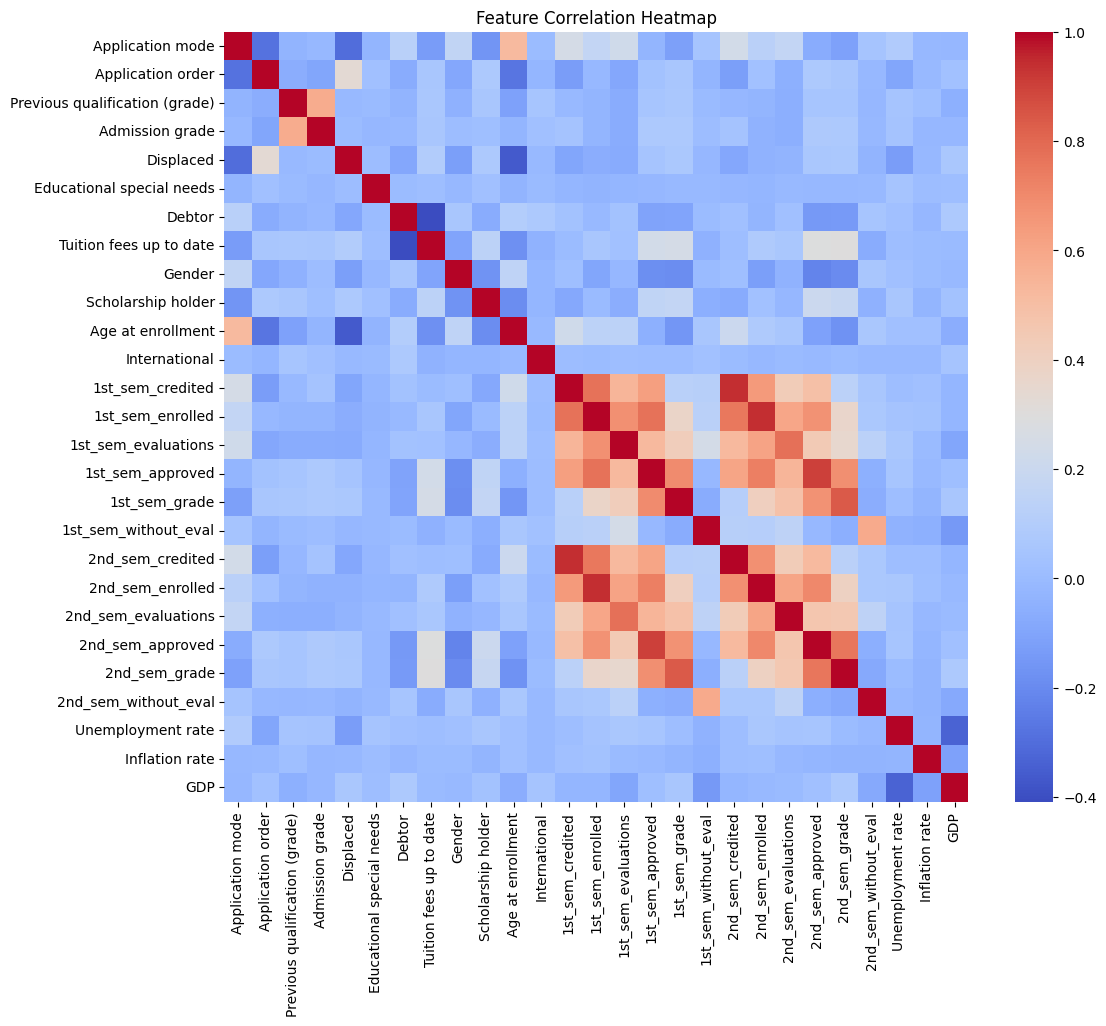

In [39]:
# Create a correlation matrix for numeric columns
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()